# Speech Processing

# Assignment 8

# Name: Saran Jayakumar Palani
# Reg No: BL.EN.U4AIE23131

## Objective
1. Compare DFT and DCT energy compaction on a 25 ms speech frame.
2. Visualize DFT and DCT distributions using histograms.
3. Extract MFCC features frame-wise and study temporal variation.
4. Compare first few MFCCs for the first two frames and infer phonetic variation.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import dct

plt.style.use('seaborn-v0_8-whitegrid')

## Assignment 7.1: DFT vs DCT Energy Compaction

NameError: name 'audio_file' is not defined

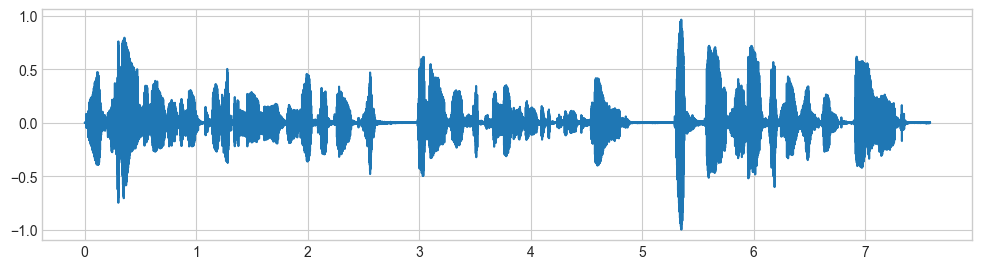

In [ ]:
fs, x = wavfile.read('test.wav')
x = x.astype(np.float64)
if x.ndim > 1:
    x = np.mean(x, axis=1)
x = x / (np.max(np.abs(x)) + 1e-12)
t = np.arange(len(x)) / fs

plt.figure(figsize=(12, 3))
plt.plot(t, x)
plt.title('Speech Signal (test.wav)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.xlim(0, t[-1])
plt.show()

print('File: test.wav')
print('Sampling rate:', fs, 'Hz')

In [ ]:
frame_len = int(0.025 * fs)
frame = x[:frame_len]
if len(frame) < frame_len:
    frame = np.pad(frame, (0, frame_len - len(frame)))
w = np.hamming(frame_len)
frame_w = frame * w

X_dft = np.fft.rfft(frame_w)
mag_dft = np.abs(X_dft)
pow_dft = mag_dft ** 2

X_dct = dct(frame_w, type=2, norm='ortho')
mag_dct = np.abs(X_dct)
pow_dct = mag_dct ** 2

cum_dft = np.cumsum(pow_dft) / (np.sum(pow_dft) + 1e-12)
cum_dct = np.cumsum(pow_dct) / (np.sum(pow_dct) + 1e-12)

k_values = [5, 10, 20, 30, 50]
print('Energy compaction (fraction of total energy in first K coefficients)')
for k in k_values:
    k_dft = min(k, len(cum_dft))
    k_dct = min(k, len(cum_dct))
    print(f'K={k:>2}: DFT={cum_dft[k_dft-1]:.4f}, DCT={cum_dct[k_dct-1]:.4f}')

In [ ]:
f_dft = np.fft.rfftfreq(frame_len, d=1/fs)
k_dct = np.arange(len(mag_dct))

fig, ax = plt.subplots(2, 2, figsize=(13, 8))

ax[0, 0].plot(f_dft, mag_dft, color='tab:blue')
ax[0, 0].set_title('DFT Magnitude (First 25 ms Frame)')
ax[0, 0].set_xlabel('Frequency (Hz)')
ax[0, 0].set_ylabel('Magnitude')

ax[0, 1].plot(k_dct, mag_dct, color='tab:orange')
ax[0, 1].set_title('DCT Magnitude (First 25 ms Frame)')
ax[0, 1].set_xlabel('Coefficient Index')
ax[0, 1].set_ylabel('Magnitude')

ax[1, 0].plot(np.arange(1, len(cum_dft) + 1), cum_dft, label='DFT', linewidth=2)
ax[1, 0].plot(np.arange(1, len(cum_dct) + 1), cum_dct, label='DCT', linewidth=2)
ax[1, 0].set_title('Cumulative Energy Compaction')
ax[1, 0].set_xlabel('Number of Coefficients')
ax[1, 0].set_ylabel('Cumulative Energy Ratio')
ax[1, 0].set_ylim(0, 1.02)
ax[1, 0].legend()

ax[1, 1].hist(mag_dft, bins=40, alpha=0.65, label='DFT', color='tab:blue')
ax[1, 1].hist(mag_dct, bins=40, alpha=0.65, label='DCT', color='tab:orange')
ax[1, 1].set_title('Histogram of Coefficient Magnitudes')
ax[1, 1].set_xlabel('Magnitude')
ax[1, 1].set_ylabel('Count')
ax[1, 1].legend()

plt.tight_layout()
plt.show()

DCT reaches high cumulative energy with fewer coefficients than DFT for this frame, indicating stronger energy compaction. Histogram concentration toward smaller magnitudes with a few dominant DCT coefficients supports this behavior.

## Assignment 7.2: MFCC Extraction and Analysis

In [ ]:
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700.0)

def mel_to_hz(m):
    return 700 * (10 ** (m / 2595.0) - 1)

def mel_filterbank(n_filters, n_fft, fs, f_min=0, f_max=None):
    if f_max is None:
        f_max = fs / 2
    mels = np.linspace(hz_to_mel(f_min), hz_to_mel(f_max), n_filters + 2)
    hz = mel_to_hz(mels)
    bins = np.floor((n_fft + 1) * hz / fs).astype(int)
    fb = np.zeros((n_filters, n_fft // 2 + 1))
    for i in range(1, n_filters + 1):
        l, c, r = bins[i - 1], bins[i], bins[i + 1]
        if c == l:
            c += 1
        if r == c:
            r += 1
        for k in range(l, c):
            if 0 <= k < fb.shape[1]:
                fb[i - 1, k] = (k - l) / (c - l)
        for k in range(c, r):
            if 0 <= k < fb.shape[1]:
                fb[i - 1, k] = (r - k) / (r - c)
    return fb

def compute_mfcc(sig, fs, frame_ms=25, hop_ms=10, n_fft=512, n_mels=26, n_mfcc=13):
    sig = np.append(sig[0], sig[1:] - 0.97 * sig[:-1])
    frame_len = int(frame_ms * fs / 1000)
    hop_len = int(hop_ms * fs / 1000)
    n_frames = 1 + int(np.floor((len(sig) - frame_len) / hop_len)) if len(sig) >= frame_len else 1

    pad_len = n_frames * hop_len + frame_len
    pad_sig = np.pad(sig, (0, max(0, pad_len - len(sig))))

    idx = np.tile(np.arange(frame_len), (n_frames, 1)) + np.tile(np.arange(n_frames) * hop_len, (frame_len, 1)).T
    frames = pad_sig[idx] * np.hamming(frame_len)

    mag = np.abs(np.fft.rfft(frames, n=n_fft))
    power = (1.0 / n_fft) * (mag ** 2)

    fb = mel_filterbank(n_mels, n_fft, fs)
    mel_energy = np.dot(power, fb.T)
    mel_energy = np.where(mel_energy == 0, np.finfo(float).eps, mel_energy)
    log_mel = np.log(mel_energy)

    coeffs = dct(log_mel, type=2, axis=1, norm='ortho')[:, :n_mfcc]
    times = (np.arange(n_frames) * hop_len + frame_len / 2) / fs
    return coeffs, times

mfcc, mfcc_t = compute_mfcc(x, fs, frame_ms=25, hop_ms=10, n_fft=512, n_mels=26, n_mfcc=13)
print('MFCC shape:', mfcc.shape)

In [ ]:
plt.figure(figsize=(12, 5))
plt.imshow(mfcc.T, aspect='auto', origin='lower', extent=[mfcc_t[0], mfcc_t[-1], 1, mfcc.shape[1]], cmap='magma')
plt.colorbar(label='Coefficient Value')
plt.title('MFCC Coefficients Over Time')
plt.xlabel('Time (s)')
plt.ylabel('MFCC Index')
plt.show()

In [ ]:
n_show = min(13, mfcc.shape[1])
idx = np.arange(1, n_show + 1)

plt.figure(figsize=(10, 4))
plt.plot(idx, mfcc[0, :n_show], marker='o', linewidth=2, label='Frame 1')
if mfcc.shape[0] > 1:
    plt.plot(idx, mfcc[1, :n_show], marker='s', linewidth=2, label='Frame 2')
plt.title('First Few MFCCs: First Two Frames')
plt.xlabel('MFCC Index')
plt.ylabel('Coefficient Value')
plt.xticks(idx)
plt.legend()
plt.show()

MFCC trajectories vary across frames as spectral envelope changes with articulation. Differences between the first two-frame MFCC patterns indicate changing vocal tract configuration, which captures phonetic variation in speech.